# Pipeline Evaluation
Reads `outputs/privacy/` and `outputs/medical/`. No pipeline code here.

In [13]:
import json, glob
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

privacy = [json.loads(f.read_text()) for f in sorted(Path('../outputs/privacy').glob('*_privacy.json'))]
medical = [json.loads(f.read_text()) for f in sorted(Path('../outputs/medical').glob('*_medical.json'))]
print(f'{len(privacy)} privacy records, {len(medical)} medical records')

11 privacy records, 5 medical records


,note_id,pii_count,pii_labels,model
0,note_001_copd,6,"MRN, date_of_birth, email, first_name, phone_n...",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
1,note_002_ra,8,"MRN, age, date_of_birth, email, first_name, ph...",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
2,note_003_ami,7,"MRN, age, date, email, first_name, phone_number",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
3,note_004_diabetes,8,"MRN, age, date_of_birth, email, first_name, oc...",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
4,note_005_oncology,8,"MRN, age, blood_type, date, email, first_name",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
5,note_006_stroke,10,"MRN, age, date_of_birth, email, first_name, ph...",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
6,note_007_sepsis,8,"MRN, age, date, email, first_name, phone_number",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
7,note_008_depression,7,"MRN, age, date, email, first_name, phone_number",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
8,note_009_ckd,10,"MRN, age, date, email, first_name, occupation,...",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1
9,note_010_asthma_paeds,8,"MRN, age, date, email, first_name, phone_number",OpenMed/OpenMed-PII-GTEMed-Base-149M-v1


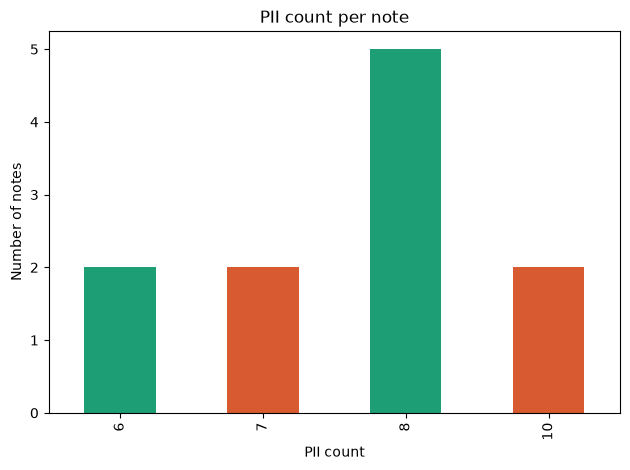

In [14]:
# Gate results
gate_df = pd.DataFrame([{
    'note_id': r['note_id'],
    'pii_count': len(r.get('pii_entities', [])),
    'pii_labels': ', '.join(sorted({e.get('label', '') for e in r.get('pii_entities', [])})),
    'model': r.get('model'),
} for r in privacy])
display(gate_df)
gate_df['pii_count'].value_counts().sort_index().plot.bar(
    color=['#1D9E75','#D85A30'], title='PII count per note')
plt.xlabel('PII count')
plt.ylabel('Number of notes')
plt.tight_layout(); plt.show()

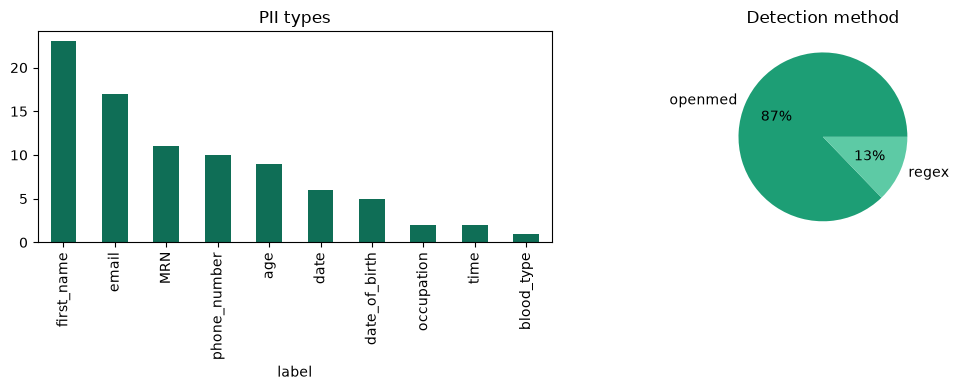

In [15]:
# PII label distribution
pii_rows = [{'note_id': r['note_id'], **e} for r in privacy for e in r['pii_entities']]
pii_df = pd.DataFrame(pii_rows)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
pii_df['label'].value_counts().plot.bar(ax=axes[0], color='#0F6E56', title='PII types')
pii_df['method'].value_counts().plot.pie(ax=axes[1], autopct='%1.0f%%',
    colors=['#1D9E75','#5DCAA5'], title='Detection method')
plt.tight_layout(); plt.show()

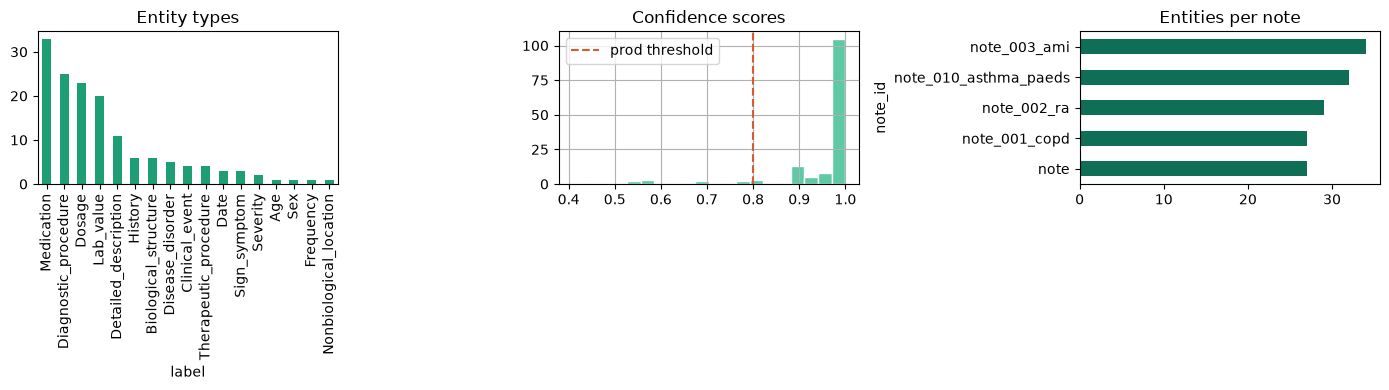

In [16]:
# Clinical entity distribution and confidence scores
ent_rows = [{'note_id': r['note_id'], **e} for r in medical for e in r['entities']]
ent_df = pd.DataFrame(ent_rows)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ent_df['label'].value_counts().plot.bar(ax=axes[0], color='#1D9E75', title='Entity types')
ent_df['score'].hist(ax=axes[1], bins=20, color='#5DCAA5', edgecolor='white')
axes[1].axvline(0.8, color='#D85A30', linestyle='--', label='prod threshold')
axes[1].set_title('Confidence scores'); axes[1].legend()
ent_df.groupby('note_id')['label'].count().sort_values().plot.barh(
    ax=axes[2], color='#0F6E56', title='Entities per note')
plt.tight_layout(); plt.show()

In [17]:
# Entities that would be filtered in production (score < 0.80)
review = ent_df[ent_df['score'] < 0.80][['note_id','text','label','score']].sort_values('score')
print(f'{len(review)} entities below production threshold:')
display(review.head(20))

13 entities below production threshold:


,note_id,text,label,score
104,note_010_asthma_paeds,x,Dosage,0.408
26,note_001_copd,5,Lab_value,0.554
148,note,5,Lab_value,0.554
27,note_002_ra,do,Diagnostic_procedure,0.556
121,note_010_asthma_paeds,3,Lab_value,0.568
63,note_003_ami,leads,Diagnostic_procedure,0.582
29,note_002_ra,] - year -,Date,0.638
49,note_002_ra,cr,Diagnostic_procedure,0.685
95,note_010_asthma_paeds,muscle,Biological_structure,0.690
39,note_002_ra,2,Lab_value,0.726
